Balaji Fast Food Sales Analysis

1.Introduction

This project analyzes the Balaji Fast Food Sales dataset to understand sales performance, customer purchasing patterns, product demand, transaction behavior, and sales trends.

The analysis includes data inspection, data preprocessing, exploratory data analysis, visualization, and generation of meaningful business insights.

To import the libraries required for data preprocessing, analysis, and visualization.
pandas – Used to load and manipulate the dataset.
numpy – Used for numerical calculations.
matplotlib.pyplot – Used to create graphs and charts.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv(r"C:\Users\PRANAY\Downloads\Project Files\Datasets\Balaji Fast Food Sales.csv")#load dataset

 Dataset Inspection

In [66]:
df.shape #dimesions 

(1000, 10)

In [67]:
df.columns

Index(['order_id', 'date', 'item_name', 'item_type', 'item_price', 'quantity',
       'transaction_amount', 'transaction_type', 'received_by',
       'time_of_sale'],
      dtype='object')

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    893 non-null    object
 8   received_by         1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [69]:
df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


In [70]:
df.tail() #last five rows

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
995,996,3/19/2023,Frankie,Fastfood,50,10,500,NaN,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,NaN,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,NaN,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,NaN,Mrs.,Afternoon
999,1000,5/29/2022,Aalopuri,Fastfood,20,3,60,Online,Mrs.,Midnight


In [71]:
df.sample(5, random_state=42) #any five random rows

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
521,522,12/29/2022,Panipuri,Fastfood,20,13,260,Cash,Mrs.,Midnight
737,738,03-01-2023,Sandwich,Fastfood,60,4,240,Online,Mrs.,Morning
740,741,7/16/2022,Aalopuri,Fastfood,20,5,100,Online,Mr.,Afternoon
660,661,10-11-2022,Frankie,Fastfood,50,7,350,Online,Mrs.,Midnight
411,412,03-09-2023,Sugarcane juice,Beverages,25,14,350,NaN,Mr.,Afternoon


Statistical Inspection

In [72]:
df.describe() #To generate a statistical summary of the numerical columns in the dataset.

,order_id,item_price,quantity,transaction_amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,33.315000,8.162000,275.230000
std,288.819436,14.921744,4.413075,204.402979
min,1.000000,20.000000,1.000000,20.000000
25%,250.750000,20.000000,4.000000,120.000000
50%,500.500000,25.000000,8.000000,240.000000
75%,750.250000,50.000000,12.000000,360.000000
max,1000.000000,60.000000,15.000000,900.000000


In [73]:
df.describe(include='object') #To generate a statistical summary of the categorical/object columns.

,date,item_name,item_type,transaction_type,received_by,time_of_sale
count,1000,1000,1000,893,1000,1000
unique,348,7,2,2,2,5
top,10-11-2022,Cold coffee,Fastfood,Cash,Mr.,Night
freq,8,161,686,476,512,205


In [74]:
df.isnull().sum() #Missing Values

order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

In [75]:
df.duplicated().sum() #check duplicate rows

0

In [76]:
df.nunique() # no of unique values in each column

order_id              1000
date                   348
item_name                7
item_type                2
item_price               5
quantity                15
transaction_amount      48
transaction_type         2
received_by              2
time_of_sale             5
dtype: int64

In [77]:
df['item_name'].unique()

array(['Aalopuri', 'Vadapav', 'Sugarcane juice', 'Panipuri', 'Frankie',
       'Sandwich', 'Cold coffee'], dtype=object)

In [78]:
df['item_type'].unique()


array(['Fastfood', 'Beverages'], dtype=object)

In [79]:
df['transaction_type'].unique()

array([nan, 'Cash', 'Online'], dtype=object)

In [80]:
df['received_by'].unique()

array(['Mr.', 'Mrs.'], dtype=object)

In [81]:
df['time_of_sale'].unique()

array(['Night', 'Afternoon', 'Evening', 'Morning', 'Midnight'],
      dtype=object)

DATA PREPROCESSING

In [82]:
df.isnull().sum() #count of missing values

order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

In [83]:
df['transaction_type'] = df['transaction_type'].fillna('Unknown')
#Cash or Online?,replace them with Unknown.

In [84]:
df.isnull().sum()

order_id              0
date                  0
item_name             0
item_type             0
item_price            0
quantity              0
transaction_amount    0
transaction_type      0
received_by           0
time_of_sale          0
dtype: int64

In [85]:
df.duplicated().sum() #check for duplicates

0

In [86]:
df['date'] = pd.to_datetime(df['date'], format='mixed')
#A date stored as text is difficult to analyze; converting it to datetime makes it suitable for time-based sales analysis.

In [87]:
df['date'].dtype

dtype('<M8[ns]')

In [88]:
#Check for negative values
print("Negative item prices:", (df['item_price'] < 0).sum())
print("Negative quantities:", (df['quantity'] < 0).sum())
print("Negative transaction amounts:", (df['transaction_amount'] < 0).sum())

Negative item prices: 0
Negative quantities: 0
Negative transaction amounts: 0


In [89]:
#Check for zero values
print("Zero item prices:", (df['item_price'] == 0).sum())
print("Zero quantities:", (df['quantity'] == 0).sum())
print("Zero transaction amounts:", (df['transaction_amount'] == 0).sum())

Zero item prices: 0
Zero quantities: 0
Zero transaction amounts: 0


The transaction amount should equal: Item Price × Quantity

In [90]:
df['calculated_amount'] = df['item_price'] * df['quantity']

In [91]:
(df['calculated_amount'] != df['transaction_amount']).sum()

0

In [92]:
df.drop('calculated_amount',axis=1, inplace=True)

In [93]:
#Check Categorical Values
print("Item Names:")
print(df['item_name'].unique())

print("\nItem Types:")
print(df['item_type'].unique())

print("\nTransaction Types:")
print(df['transaction_type'].unique())

print("\nReceived By:")
print(df['received_by'].unique())

print("\nTime of Sale:")
print(df['time_of_sale'].unique())

Item Names:
['Aalopuri' 'Vadapav' 'Sugarcane juice' 'Panipuri' 'Frankie' 'Sandwich'
 'Cold coffee']

Item Types:
['Fastfood' 'Beverages']

Transaction Types:
['Unknown' 'Cash' 'Online']

Received By:
['Mr.' 'Mrs.']

Time of Sale:
['Night' 'Afternoon' 'Evening' 'Morning' 'Midnight']


In [94]:
#To identify unusually high or low values that may affect the accuracy of sales analysis.
Q1 = df['transaction_amount'].quantile(0.25)
Q3 = df['transaction_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -240.0
Upper Bound: 720.0


In [95]:
outliers = df[
    (df['transaction_amount'] < lower_bound) |
    (df['transaction_amount'] > upper_bound)
]

print("Number of outliers:", len(outliers))


Number of outliers: 44


In [96]:
#preprocessed data
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1000, 10)

Missing Values:
order_id              0
date                  0
item_name             0
item_type             0
item_price            0
quantity              0
transaction_amount    0
transaction_type      0
received_by           0
time_of_sale          0
dtype: int64

Duplicate Records: 0

Data Types:
order_id                       int64
date                  datetime64[ns]
item_name                     object
item_type                     object
item_price                     int64
quantity                       int64
transaction_amount             int64
transaction_type              object
received_by                   object
time_of_sale                  object
dtype: object


In [97]:
df.to_csv("Balaji_Fast_Food_Sales_Cleaned.csv", index=False)

Data visualisation

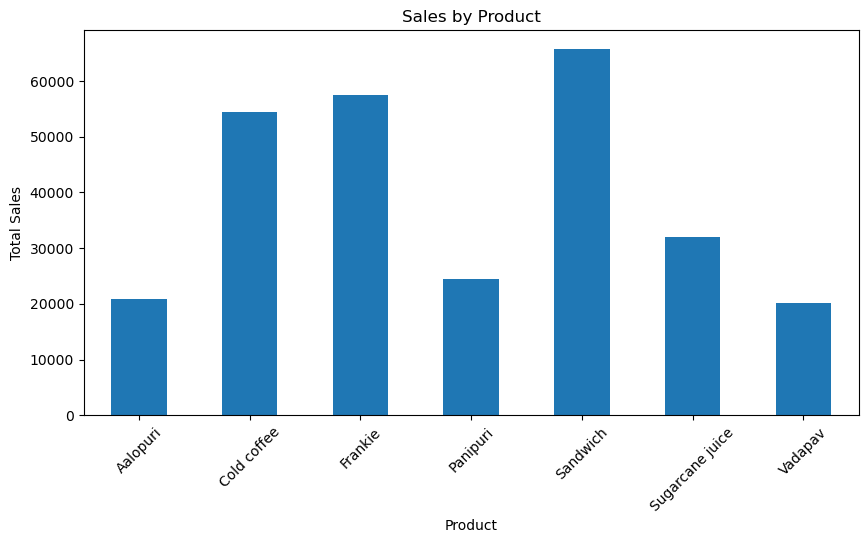

In [98]:

sales_by_product = df.groupby('item_name')['transaction_amount'].sum()

sales_by_product.plot(kind='bar', figsize=(10,5))

plt.title('Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

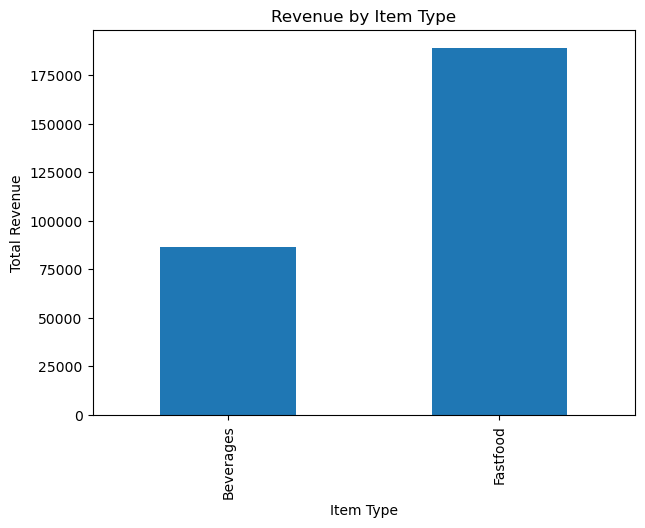

In [99]:
revenue_by_type = df.groupby('item_type')['transaction_amount'].sum()

revenue_by_type.plot(kind='bar', figsize=(7,5))

plt.title('Revenue by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Total Revenue')
plt.show()

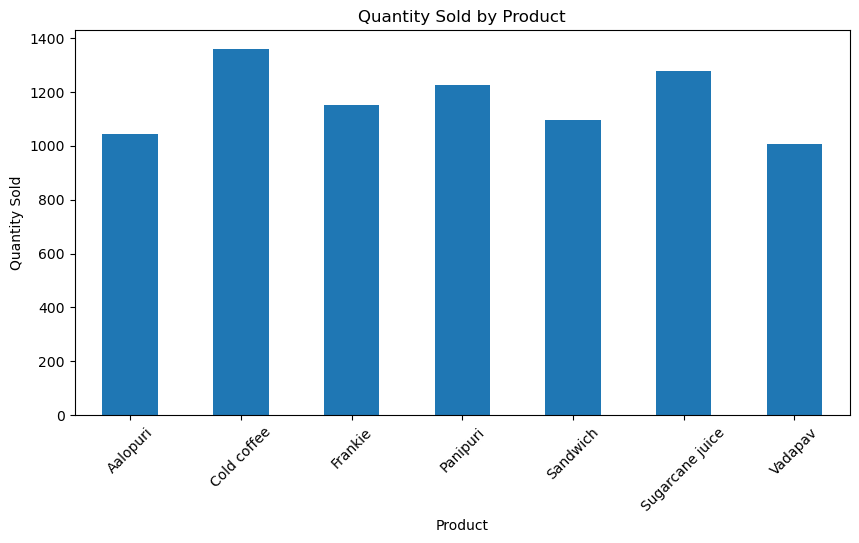

In [100]:
quantity_by_product = df.groupby('item_name')['quantity'].sum()

quantity_by_product.plot(kind='bar', figsize=(10,5))

plt.title('Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

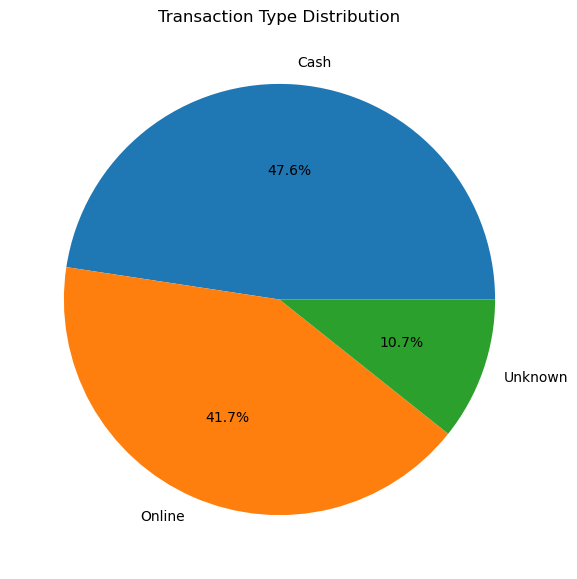

In [101]:
transaction_counts = df['transaction_type'].value_counts()

transaction_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))

plt.title('Transaction Type Distribution')
plt.ylabel('')
plt.show()

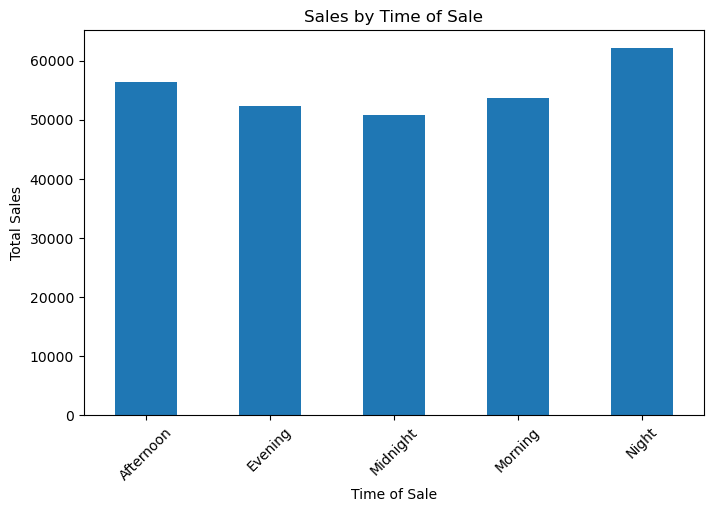

In [102]:
sales_by_time = df.groupby('time_of_sale')['transaction_amount'].sum()

sales_by_time.plot(kind='bar', figsize=(8,5))

plt.title('Sales by Time of Sale')
plt.xlabel('Time of Sale')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

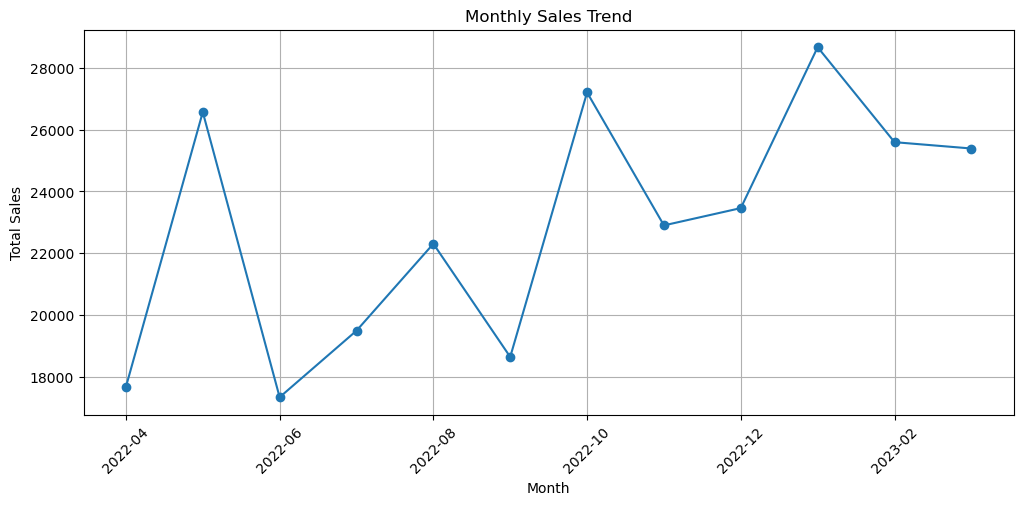

In [103]:
monthly_sales = df.groupby(df['date'].dt.to_period('M'))['transaction_amount'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot(kind='line', figsize=(12,5), marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid()
plt.show()

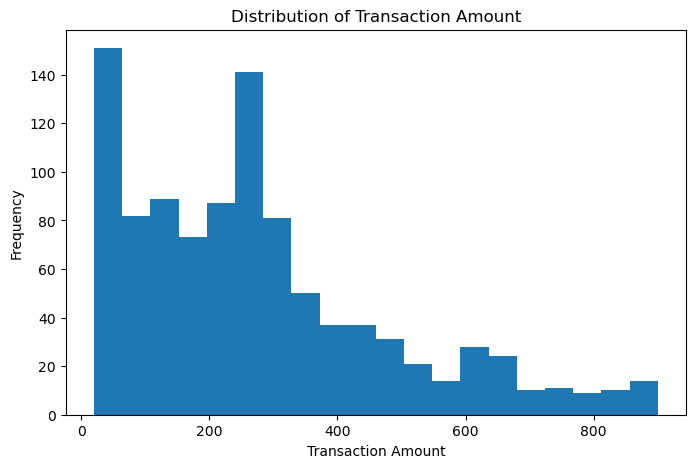

In [104]:
plt.figure(figsize=(8,5))

plt.hist(df['transaction_amount'], bins=20)

plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

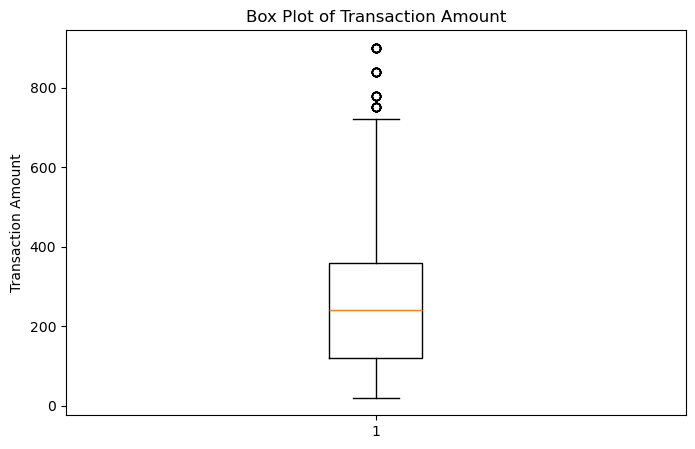

In [105]:
plt.figure(figsize=(8,5))

plt.boxplot(df['transaction_amount'])

plt.title('Box Plot of Transaction Amount')
plt.ylabel('Transaction Amount')
plt.show()

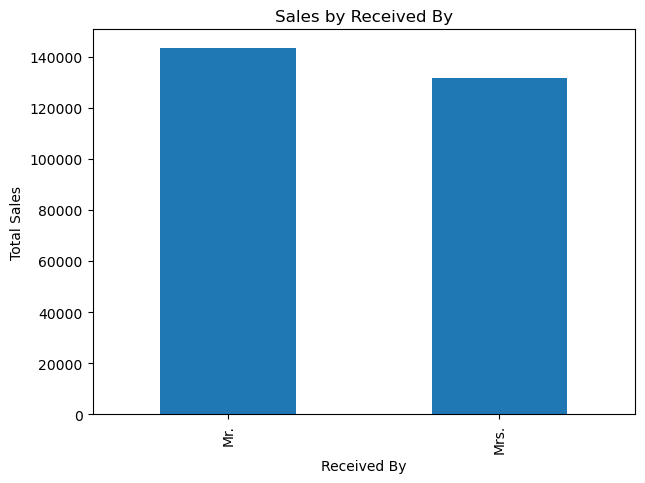

In [106]:
sales_by_receiver = df.groupby('received_by')['transaction_amount'].sum()

sales_by_receiver.plot(kind='bar', figsize=(7,5))

plt.title('Sales by Received By')
plt.xlabel('Received By')
plt.ylabel('Total Sales')
plt.show()